# Movie Recommendation System using KNN

This project uses the MovieLens 100K dataset to build a movie recommendation system using the K-Nearest Neighbors (KNN) algorithm. The system identifies movies with similar user rating patterns and recommends movies based on a selected movie.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings("ignore")

In [ ]:
ratings = pd.read_csv(
    "/content/u.data",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)
movie_columns = [
    "movieId", "title", "release_date", "video_release_date",
    "IMDb_URL", "unknown", "Action", "Adventure", "Animation",
    "Children", "Comedy", "Crime", "Documentary", "Drama",
    "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
    "Romance", "Sci-Fi", "Thriller", "War", "Western"
]

movies = pd.read_csv(
    "/content/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)
print(movies.shape)
print(ratings.shape)

(1682, 24)
(100000, 4)


In [ ]:
print(ratings.shape)
print(ratings.head())
print(ratings.columns)

(100000, 4)
   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')


In [ ]:
movies.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
ratings.head()

,user_id,movie_Id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
#check missing values
print("Movies Dataset\n")
print(movies.isnull().sum())

print("\n")

print("Ratings Dataset\n")
print(ratings.isnull().sum())

Movies Dataset

0        0
1        0
2        1
3     1682
4        3
5        0
6        0
7        0
8        0
9        0
10       0
11       0
12       0
13       0
14       0
15       0
16       0
17       0
18       0
19       0
20       0
21       0
22       0
23       0
dtype: int64


Ratings Dataset

user_id      0
movie_Id     0
rating       0
timestamp    0
dtype: int64


In [ ]:
print(ratings.shape)
print(movies.shape)
print(ratings.head())
print(movies.head())

(100000, 4)
(1682, 24)
   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596
   0                  1            2   3   \
0   1   Toy Story (1995)  01-Jan-1995 NaN   
1   2   GoldenEye (1995)  01-Jan-1995 NaN   
2   3  Four Rooms (1995)  01-Jan-1995 NaN   
3   4  Get Shorty (1995)  01-Jan-1995 NaN   
4   5     Copycat (1995)  01-Jan-1995 NaN   

                                                  4   5   6   7   8   9   ...  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...   0   0   0   1   1  ...   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...   0   1   1   0   0  ...   
2  http://us.imdb.com/M/title-exact?Four%20Rooms%...   0   0   0   0   0  ...   
3  http://us.imdb.com/M/title-exact?Get%20Shorty%...   0   1   0   0   0  ...   
4  http://us.imdb.com/M/title-exact?Copycat%20(1995)   0   0   0   0   0 

In [ ]:
print(ratings.columns)
print(movies.columns)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23],
      dtype='int64')


In [ ]:
movie_columns = [
    "movieId", "title", "release_date", "video_release_date",
    "IMDb_URL", "unknown", "Action", "Adventure", "Animation",
    "Children", "Comedy", "Crime", "Documentary", "Drama",
    "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
    "Romance", "Sci-Fi", "Thriller", "War", "Western"
]

movies.columns = movie_columns

print("Number of Movies :", movies['movieId'].nunique())

print("Number of Users :", ratings['userId'].nunique())

print("Total Ratings :", ratings.shape[0])

Number of Movies : 1682
Number of Users : 943
Total Ratings : 100000


In [ ]:
movie_data=pd.merge(ratings,movies,on="movieId")
movie_data.head()

,userId,movieId,rating,timestamp,title,release_date,video_release_date,IMDb_URL,unknown,Action,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:

movie_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   userId              100000 non-null  int64  
 1   movieId             100000 non-null  int64  
 2   rating              100000 non-null  int64  
 3   timestamp           100000 non-null  int64  
 4   title               100000 non-null  object 
 5   release_date        99991 non-null   object 
 6   video_release_date  0 non-null       float64
 7   IMDb_URL            99987 non-null   object 
 8   unknown             100000 non-null  int64  
 9   Action              100000 non-null  int64  
 10  Adventure           100000 non-null  int64  
 11  Animation           100000 non-null  int64  
 12  Children            100000 non-null  int64  
 13  Comedy              100000 non-null  int64  
 14  Crime               100000 non-null  int64  
 15  Documentary         100000 non-null

In [ ]:
movie_data.sample(10)

,userId,movieId,rating,timestamp,title,release_date,video_release_date,IMDb_URL,unknown,Action,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
61820,666,137,4,880313423,Big Night (1996),20-Sep-1996,NaN,http://us.imdb.com/M/title-exact?Big%20Night%2...,0,0,...,0,0,0,0,0,0,0,0,0,0
67589,622,253,3,882591047,"Pillow Book, The (1995)",13-Jun-1997,NaN,http://us.imdb.com/M/title-exact?Pillow%20Book...,0,0,...,0,0,0,0,0,1,0,0,0,0
91800,926,272,5,888351623,Good Will Hunting (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,...,0,0,0,0,0,0,0,0,0,0
43,276,564,3,874791805,Tales from the Hood (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Tales%20from%...,0,0,...,0,0,1,0,0,0,0,0,0,0
64015,759,1,5,875227798,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,...,0,0,0,0,0,0,0,0,0,0
937,7,554,3,891354639,Waterworld (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Waterworld%20...,0,1,...,0,0,0,0,0,0,0,0,0,0
45896,334,508,3,891544867,"People vs. Larry Flynt, The (1996)",27-Dec-1996,NaN,http://us.imdb.com/M/title-exact?People%20vs.%...,0,0,...,0,0,0,0,0,0,0,0,0,0
88328,816,243,4,891711554,Jungle2Jungle (1997),07-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Jungle2Jungle...,0,0,...,0,0,0,0,0,0,0,0,0,0
98697,342,507,4,875319295,"Streetcar Named Desire, A (1951)",01-Jan-1951,NaN,http://us.imdb.com/M/title-exact?Streetcar%20N...,0,0,...,0,0,0,0,0,0,0,0,0,0
86078,645,182,5,892053686,GoodFellas (1990),01-Jan-1990,NaN,http://us.imdb.com/M/title-exact?GoodFellas%20...,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print("Movie Data Statistics\n")

movie_data.describe()

Movie Data Statistics



,userId,movieId,rating,timestamp,video_release_date,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
count,100000.00000,100000.000000,100000.000000,1.000000e+05,0.0,100000.0000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.00000,100000.000000,100000.000000
mean,462.48475,425.530130,3.529860,8.835289e+08,NaN,0.0001,0.255890,0.137530,0.036050,0.071820,...,0.013520,0.017330,0.053170,0.049540,0.052450,0.194610,0.12730,0.21872,0.093980,0.018540
std,266.61442,330.798356,1.125674,5.343856e+06,NaN,0.0100,0.436362,0.344408,0.186416,0.258191,...,0.115487,0.130498,0.224373,0.216994,0.222934,0.395902,0.33331,0.41338,0.291802,0.134894
min,1.00000,1.000000,1.000000,8.747247e+08,NaN,0.0000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
25%,254.00000,175.000000,3.000000,8.794487e+08,NaN,0.0000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
50%,447.00000,322.000000,4.000000,8.828269e+08,NaN,0.0000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
75%,682.00000,631.000000,4.000000,8.882600e+08,NaN,0.0000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
max,943.00000,1682.000000,5.000000,8.932866e+08,NaN,1.0000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.00000,1.000000,1.000000


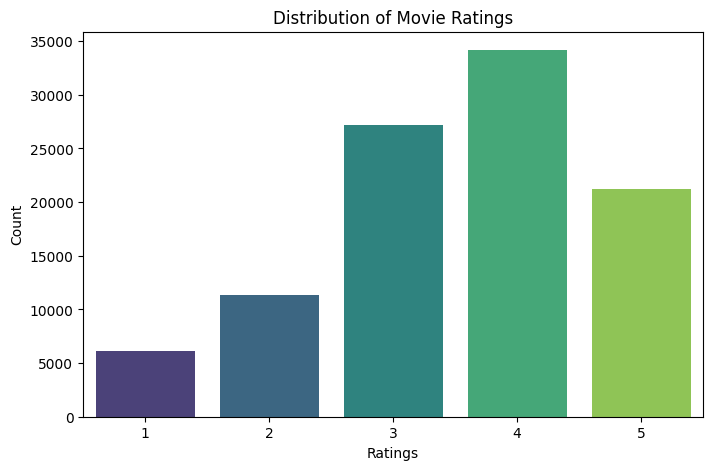

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='rating',
    data=movie_data,
    palette='viridis'
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Ratings")
plt.ylabel("Count")

plt.show()

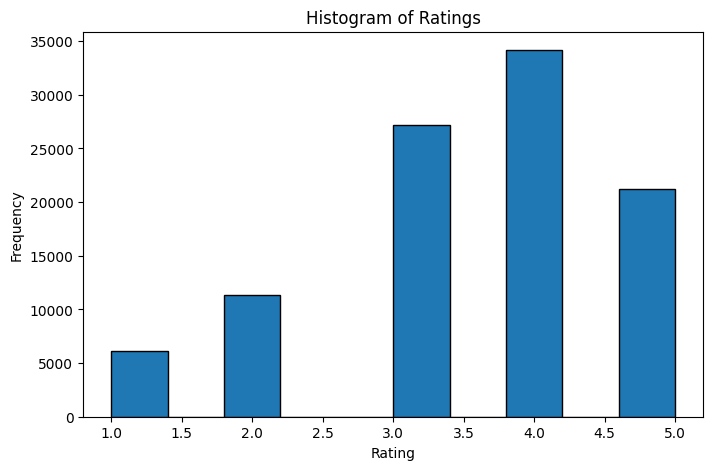

In [ ]:
#histogram of ratings
plt.figure(figsize=(8,5))

movie_data['rating'].hist(
    bins=10,
    edgecolor='black'
)

plt.title("Histogram of Ratings")

plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.grid(False)

plt.show()

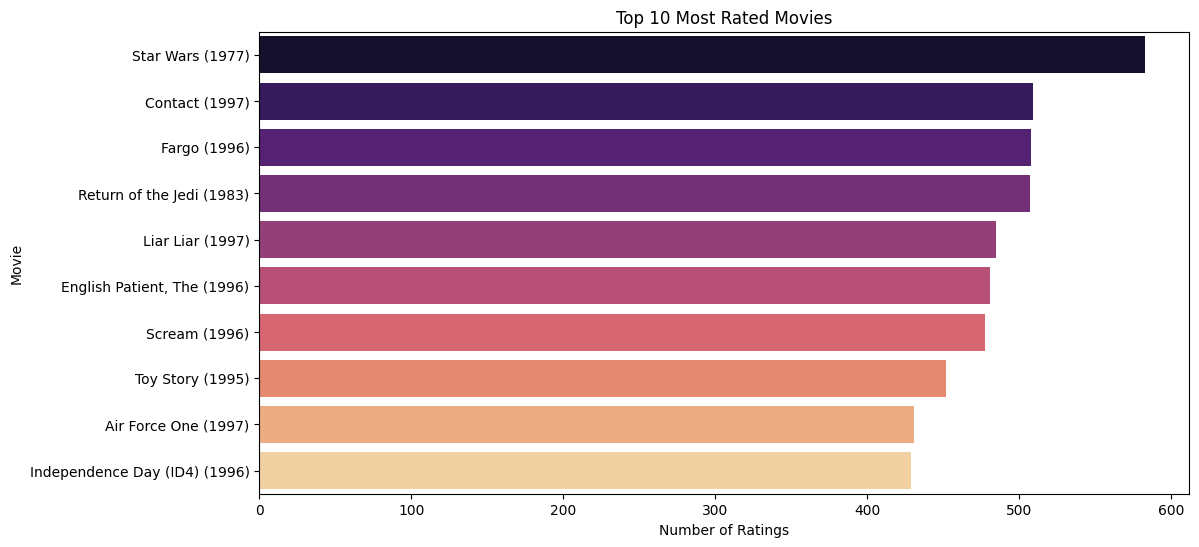

In [ ]:
#top 10 most rated movies

movie_rating_count = movie_data.groupby('title')['rating'].count().sort_values(ascending=False)
top_movies=movie_rating_count.head(10)
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_movies.values,
    y=top_movies.index,
    palette="magma"
)

plt.title("Top 10 Most Rated Movies")

plt.xlabel("Number of Ratings")

plt.ylabel("Movie")

plt.show()

In [ ]:
#ratings given by the user
user_rating_count = movie_data.groupby('userId')['rating'].count()

user_rating_count.describe()

,rating
count,943.000000
mean,106.044539
std,100.931743
min,20.000000
25%,33.000000
50%,65.000000
75%,148.000000
max,737.000000


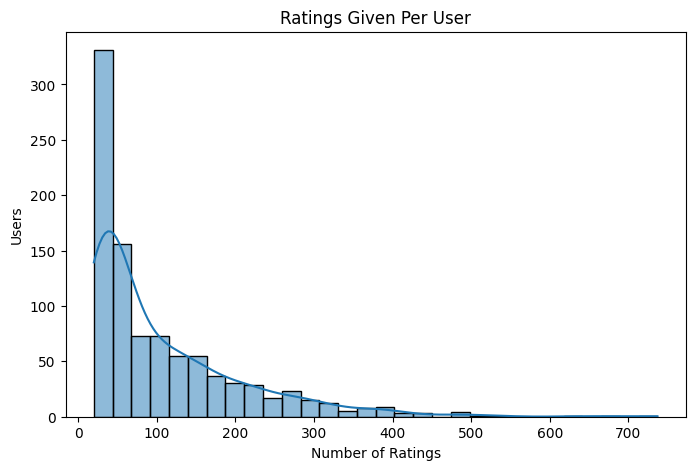

In [ ]:
#plot the distribtuion given by the user
plt.figure(figsize=(8,5))

sns.histplot(
    user_rating_count,
    bins=30,
    kde=True
)

plt.title("Ratings Given Per User")

plt.xlabel("Number of Ratings")

plt.ylabel("Users")

plt.show()

In [ ]:
movie_average=movie_data.groupby('title')['rating'].mean()
movie_average.sort_values(ascending=False).head(10)

,rating
title,
Aiqing wansui (1994),5.0
Entertaining Angels: The Dorothy Day Story (1996),5.0
Santa with Muscles (1996),5.0
Prefontaine (1997),5.0
They Made Me a Criminal (1939),5.0
"Saint of Fort Washington, The (1993)",5.0
"Great Day in Harlem, A (1994)",5.0
Star Kid (1997),5.0
Marlene Dietrich: Shadow and Light (1996),5.0


In [ ]:
#movie statistics
movie_stats = movie_data.groupby('title').agg(
    Average_Rating=('rating','mean'),
    Number_of_Ratings=('rating','count')
)

movie_stats.head()

,Average_Rating,Number_of_Ratings
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


In [ ]:
popular_movies = movie_stats[
    movie_stats['Number_of_Ratings'] >= 100
].sort_values(
    by='Average_Rating',
    ascending=False
)

popular_movies.head(10)



,Average_Rating,Number_of_Ratings
title,,
"Close Shave, A (1995)",4.491071,112
Schindler's List (1993),4.466443,298
"Wrong Trousers, The (1993)",4.466102,118
Casablanca (1942),4.456790,243
"Shawshank Redemption, The (1994)",4.445230,283
Rear Window (1954),4.387560,209
"Usual Suspects, The (1995)",4.385768,267
Star Wars (1977),4.358491,583
12 Angry Men (1957),4.344000,125


In [ ]:
movie_stats.sort_values(
    by=["Average_Rating","Number_of_Ratings"],
    ascending=False
).head(20)

,Average_Rating,Number_of_Ratings
title,,
Prefontaine (1997),5.000000,3
Star Kid (1997),5.000000,3
"Saint of Fort Washington, The (1993)",5.000000,2
Santa with Muscles (1996),5.000000,2
Aiqing wansui (1994),5.000000,1
Entertaining Angels: The Dorothy Day Story (1996),5.000000,1
"Great Day in Harlem, A (1994)",5.000000,1
Marlene Dietrich: Shadow and Light (1996),5.000000,1
Someone Else's America (1995),5.000000,1


In [ ]:
movie_data.head()

,userId,movieId,rating,timestamp,title,release_date,video_release_date,IMDb_URL,unknown,Action,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,...,0,0,0,0,0,0,0,0,0,0


# Data Preprocessing & KNN Model

In [ ]:
#Remove Movies with Very Few Ratings

# Count ratings for each movie
movie_rating_counts = movie_data.groupby('title')['rating'].count()

popular_movies = movie_rating_counts[movie_rating_counts >= 20]

filtered_movie_data = movie_data[
    movie_data['title'].isin(popular_movies.index)
]

In [ ]:
#remove inactive users
# Count ratings per user
user_rating_counts = filtered_movie_data.groupby('userId')['rating'].count()

# Keep users with at least 20 ratings
active_users = user_rating_counts[user_rating_counts >= 20]

filtered_movie_data = filtered_movie_data[
    filtered_movie_data['userId'].isin(active_users.index)
]


#Create User–Movie Matrix

In [ ]:
#rows-movies
#columns=user
#values-ratings
movie_user_matrix = filtered_movie_data.pivot_table(
    index='title',
    columns='userId',
    values='rating'
)

movie_user_matrix.head()


userId,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
title,,,,,,,,,,,,,,,,,,,,,
101 Dalmatians (1996),2.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,2.0,NaN,NaN,2.0,4.0,NaN,NaN,NaN,NaN,NaN
12 Angry Men (1957),5.0,NaN,NaN,NaN,NaN,4.0,4.0,NaN,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
187 (1997),NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2 Days in the Valley (1996),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0
"20,000 Leagues Under the Sea (1954)",3.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
movie_user_matrix.fillna(0, inplace=True)

movie_user_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
title,,,,,,,,,,,,,,,,,,,,,
101 Dalmatians (1996),2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0
12 Angry Men (1957),5.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
187 (1997),0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2 Days in the Valley (1996),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
"20,000 Leagues Under the Sea (1954)",3.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print(movie_user_matrix.shape)

(931, 917)


In [ ]:
#convert this empty matrix into sparse matrix
from scipy.sparse import csr_matrix

movie_sparse_matrix = csr_matrix(movie_user_matrix.values)

print(movie_sparse_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 94193 stored elements and shape (931, 917)>
  Coords	Values
  (0, 0)	2.0
  (0, 4)	2.0
  (0, 12)	2.0
  (0, 14)	3.0
  (0, 35)	5.0
  (0, 40)	2.0
  (0, 42)	4.0
  (0, 46)	2.0
  (0, 53)	2.0
  (0, 54)	3.0
  (0, 57)	3.0
  (0, 59)	3.0
  (0, 60)	2.0
  (0, 67)	3.0
  (0, 72)	2.0
  (0, 79)	3.0
  (0, 80)	3.0
  (0, 81)	4.0
  (0, 89)	3.0
  (0, 91)	3.0
  (0, 98)	3.0
  (0, 138)	3.0
  (0, 155)	4.0
  (0, 157)	1.0
  (0, 162)	3.0
  :	:
  (930, 377)	4.0
  (930, 409)	4.0
  (930, 419)	2.0
  (930, 445)	3.0
  (930, 462)	3.0
  (930, 475)	3.0
  (930, 479)	4.0
  (930, 506)	3.0
  (930, 525)	1.0
  (930, 567)	4.0
  (930, 575)	4.0
  (930, 577)	4.0
  (930, 580)	4.0
  (930, 602)	1.0
  (930, 618)	4.0
  (930, 639)	4.0
  (930, 737)	5.0
  (930, 751)	4.0
  (930, 804)	2.0
  (930, 833)	3.0
  (930, 837)	4.0
  (930, 841)	5.0
  (930, 843)	3.0
  (930, 846)	3.0
  (930, 909)	5.0


In [ ]:
knn_model=NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=11,
    n_jobs=-1)
knn_model.fit(
movie_sparse_matrix)

NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1, n_neighbors=11)

In [ ]:
movie_user_matrix.index[:20]

Index(['101 Dalmatians (1996)', '12 Angry Men (1957)', '187 (1997)',
       '2 Days in the Valley (1996)', '20,000 Leagues Under the Sea (1954)',
       '2001: A Space Odyssey (1968)', '39 Steps, The (1935)', '8 1/2 (1963)',
       'Absolute Power (1997)', 'Abyss, The (1989)',
       'Ace Ventura: Pet Detective (1994)',
       'Ace Ventura: When Nature Calls (1995)', 'Addams Family Values (1993)',
       'Addicted to Love (1997)', 'Adventures of Pinocchio, The (1996)',
       'Adventures of Priscilla, Queen of the Desert, The (1994)',
       'Adventures of Robin Hood, The (1938)', 'Affair to Remember, An (1957)',
       'African Queen, The (1951)', 'Age of Innocence, The (1993)'],
      dtype='object', name='title')

In [ ]:
def search_movie(keyword):
    keyword = keyword.lower()

    results = [
        movie
        for movie in movie_user_matrix.index
        if keyword in movie.lower()
    ]

    return results[:20]

In [ ]:
search_movie("batman")

['Batman & Robin (1997)',
 'Batman (1989)',
 'Batman Forever (1995)',
 'Batman Returns (1992)']

In [ ]:
def recommend_movies(movie_name, n_recommendations=10):

    if movie_name not in movie_user_matrix.index:
        print("Movie not found!")
        return

    movie_index = movie_user_matrix.index.get_loc(movie_name)

    distances, indices = knn_model.kneighbors(
        movie_user_matrix.iloc[movie_index, :].values.reshape(1, -1),
        n_neighbors=n_recommendations + 1
    )

    print("=" * 60)
    print("Selected Movie:")
    print(movie_name)
    print("=" * 60)

    print("\nRecommended Movies:\n")

    for i in range(1, len(distances.flatten())):
        print(
            f"{i}. {movie_user_matrix.index[indices.flatten()[i]]}"
            f"   (Distance = {distances.flatten()[i]:.3f})"
        )

In [ ]:
recommend_movies("Toy Story (1995)")

Selected Movie:
Toy Story (1995)

Recommended Movies:

1. Star Wars (1977)   (Distance = 0.265)
2. Return of the Jedi (1983)   (Distance = 0.298)
3. Independence Day (ID4) (1996)   (Distance = 0.308)
4. Rock, The (1996)   (Distance = 0.335)
5. Mission: Impossible (1996)   (Distance = 0.357)
6. Willy Wonka and the Chocolate Factory (1971)   (Distance = 0.361)
7. Star Trek: First Contact (1996)   (Distance = 0.362)
8. Fargo (1996)   (Distance = 0.366)
9. Raiders of the Lost Ark (1981)   (Distance = 0.375)
10. Jerry Maguire (1996)   (Distance = 0.375)
